# Inviting exploration of CMIP data in ARCO formats

This example notebook helps to see different ways to optimize a CMIP data analysis by simply interfacing with zarr, or icechunk without having to rewrite the NetCDF source completely.

Example 1- Working with CMIP6 NetCDF in AWS directly (bucket: esgf-world)

Example 2- Working with CMIP6 Zarr in GCP  

Example 3- Working with CMIP6 NetCDF source but reaping benefits of Zarr through virtualizarr and icechunk. This includes icechunk generation, and using open_zarr to read the icechunk.


Issue https://github.com/jbusecke/esgf-virtual-zarr-data-access/issues/18

If you have any questions, please open an issue here https://github.com/jbusecke/esgf-virtual-zarr-data-access.


References:
https://virtualizarr.readthedocs.io/en/stable/index.html#quick-usage-example
https://github.com/aradhakrishnanGFDL/spear_flp_sandbox/
https://icechunk.io/en/stable/
https://esgf-world.s3.amazonaws.com/index.html
https://registry.opendata.aws/cmip6/
https://pangeo-data.github.io/pangeo-cmip6-cloud/overview.html

#Example-1  Working with CMIP6 NetCDF in AWS directly (bucket: esgf-world)

In [1]:
import intake_esm
import intake

col_url = "https://raw.githubusercontent.com/aradhakrishnanGFDL/gfdl-aws-analysis/master/esm-collection-spec-examples/esgf-world.json"
col = intake.open_esm_datastore(col_url)

In [2]:
# there is currently a significant amount of data for these runs
expts = ['historical']

query_Amon = dict(
    experiment_id=expts,
    table_id='Amon',
    variable_id=['tas'],
    member_id = 'r1i1p1f1',
    source_id = ['GFDL-CM4']
)

cat_Amon = col.search(**query_Amon)
dset_dict = cat_Amon.to_dataset_dict(
    xarray_open_kwargs={
        'engine':'h5netcdf',
    },
    storage_options={
        'anon':True
    },
)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'project.institution_id.source_id.experiment_id.table_id'


<div><progress max="1" value="1"></progress> 100.00% [1/1 01:41&lt;00:00]</div>

In [5]:
dset_dict['CMIP6.NOAA-GFDL.GFDL-CM4.historical.Amon'].tas

<xarray.DataArray 'tas' (member_id: 1, time: 1980, lat: 180, lon: 288)> Size: 411MB
dask.array<concatenate, shape=(1, 1980, 180, 288), dtype=float32, chunksize=(1, 647, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) object 8B 'r1i1p1f1'
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height     float64 8B 2.0
Attributes:
    long_name:      Near-Surface Air Temperature
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    standard_name:  air_temperature
    interp_method:  conserve_order2
    original_name:  tas

In [ ]:
#Without the use of catalogs for a single file
import s3fs
import xarray as xr
%matplotlib inline
fs_s3 = s3fs.S3FileSystem(anon=True)
s3path = 's3://esgf-world/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/r1i1p1f1/Amon/tas/gr1/v20180701/tas_Amon_GFDL-CM4_historical_r1i1p1f1_gr1_185001-194912.nc'
remote_file_obj = fs_s3.open(s3path, mode='rb')

ds = xr.open_dataset(remote_file_obj, chunks={'time': 1})

ds

#Alternatively refer to intake-esm catalog based examples here https://github.com/aradhakrishnanGFDL/gfdl-aws-analysis/blob/master/examples/nino3_exercise.ipynb

<xarray.Dataset> Size: 249MB
Dimensions:    (lat: 180, bnds: 2, lon: 288, time: 1200)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * time       (time) object 10kB 1850-01-16 12:00:00 ... 1949-12-16 12:00:00
    height     float64 8B ...
Data variables:
    lat_bnds   (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 249MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    time_bnds  (time, bnds) object 19kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               Amon
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    branch_time_in_parent:  36500.0
    parent_time_units:      days since 0001-1-1

# Example 2- Working with CMIP6 Zarr in GCP


In [ ]:
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import dask
from dask.diagnostics import progress
from tqdm.autonotebook import tqdm
import intake
import fsspec
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

/tmp/ipython-input-5818/2234965176.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
#%pip install intake-esm

In [ ]:
col = intake.open_esm_datastore("https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.json")

In [ ]:
# there is currently a significant amount of data for these runs
expts = ['historical', 'ssp245', 'ssp585']

query = dict(
    experiment_id=expts,
    table_id='Amon',
    variable_id=['tas'],
    member_id = 'r1i1p1f1',
    source_id = ['GFDL-CM4','GFDL-ESM4','CAMS-CSM1-0','IPSL-CM6A-LR']
)

col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[
    ["experiment_id", "variable_id", "table_id"]
].nunique()

,experiment_id,variable_id,table_id
source_id,,,
CAMS-CSM1-0,3,1,1
GFDL-CM4,3,1,1
GFDL-ESM4,3,1,1
IPSL-CM6A-LR,3,1,1


In [ ]:
#%pip install s3fs
import s3fs

In [ ]:
dsets = col_subset.to_dataset_dict(storage_options=dict(anon=True),cdf_kwargs={'decode_times': True})

In [ ]:
ds = dsets["ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp585.Amon.gr1"]

In [ ]:
ds

<xarray.Dataset> Size: 214MB
Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 1032, lat: 180,
                     lon: 288, bnds: 2)
Coordinates:
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) object 8B None
  * time            (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:0...
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 2kB 0.625 1.875 3.125 ... 356.9 358.1 359.4
  * bnds            (bnds) float64 16B 1.0 2.0
    height          float64 8B ...
    lat_bnds        (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds        (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    time_bnds       (time, bnds) object 17kB dask.array<chunksize=(1032, 2), meta=np.ndarray>
Data variables:
    tas             (member_id, dcpp_init_year, time, lat, lon) float32 214MB dask.array<chunksize=(1, 1, 647, 180, 288), meta=np.ndarray>
Attributes: (12/60)
    Conventions:                      CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:                      ScenarioMIP
    branch_method:                    standard
    branch_time_in_child:             60225.0
    branch_time_in_parent:            60225.0
    comment:                          <null ref>
    ...                               ...
    intake_esm_attrs:variable_id:     tas
    intake_esm_attrs:grid_label:      gr1
    intake_esm_attrs:zstore:          s3://cmip6-pds/CMIP6/ScenarioMIP/NOAA-G...
    intake_esm_attrs:version:         20180701
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp585....

In [ ]:
ds.tas

<xarray.DataArray 'tas' (member_id: 1, dcpp_init_year: 1, time: 1032, lat: 180,
                         lon: 288)> Size: 214MB
dask.array<getitem, shape=(1, 1, 1032, 180, 288), dtype=float32, chunksize=(1, 1, 647, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) object 8B None
  * time            (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:0...
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 2kB 0.625 1.875 3.125 ... 356.9 358.1 359.4
    height          float64 8B ...
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

In [ ]:
from google.colab import auth
auth.authenticate_user()

# Example 3- Working with CMIP6 NetCDF source but reaping benefits of Zarr through virtualizarr and icechunk




#Virtualizarr Test
Creating a virtual dataset with the source as NetCDF


Ref https://virtualizarr.readthedocs.io/en/stable/index.html#features

In [6]:
import xarray as xr
from obstore.store import from_url
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from virtualizarr.registry import ObjectStoreRegistry
import icechunk, parquet

/tmp/ipykernel_1569/587386662.py:5: DeprecationWarning: Importing ObjectStoreRegistry from VirtualiZarr is deprecated. Please use 'from obspec_utils.registry import ObjectStoreRegistry instead.
  from virtualizarr.registry import ObjectStoreRegistry


In [5]:
#%pip install cftime obstore virtualizarr icechunk parquet
#You'll need this when you get to opening the dataset later

In [ ]:
#%pip install obstore virtualizarr icechunk fastparquet parquet obstore

In [7]:
#Zarr can emit a lot of warnings about Numcodecs not being including in
#the Zarr version 3 specification yet -- let's suppress those.

import warnings
warnings.filterwarnings(
  "ignore",
  message="Numcodecs codecs are not in the Zarr version 3 specification*",
  category=UserWarning
)

Create ObjectStore and ObjectStore registry using Obstore

In [8]:
#We can use Obstore's obstore.store.from_url convenience method to create an
#ObjectStore that can fetch data from the specified URLs.

bucket = "s3://esgf-world" # Changed from s3://esgf-world.s3 to match the s3_base_url
store = from_url(bucket, region="us-east-2", skip_signature=True)

#We also need to create an ObjectStoreRegistry
#that maps the URL structure to the ObjectStore.
registry = ObjectStoreRegistry({bucket: store})

List of files/objects

In [2]:
#%pip install s3fs
import s3fs

fs = s3fs.S3FileSystem(anon=True)  # use anon=True for public buckets
path = "esgf-world/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/r1i1p1f1/Amon/tas/gr1/v20180701/"
files = fs.ls(path)
# If you want full s3:// paths:
urls = ["s3://" + f for f in files]

#We can use Obstore's obstore.store.from_url convenience method to create an
#ObjectStore that can fetch data from the specified URLs.

In [3]:
urls = sorted(urls)
print(urls)

['s3://esgf-world/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/r1i1p1f1/Amon/tas/gr1/v20180701/tas_Amon_GFDL-CM4_historical_r1i1p1f1_gr1_185001-194912.nc', 's3://esgf-world/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/r1i1p1f1/Amon/tas/gr1/v20180701/tas_Amon_GFDL-CM4_historical_r1i1p1f1_gr1_195001-201412.nc']


Preprocess functions, handles cftime object encoding.

In [4]:
import xarray as xr
import cftime


def preprocess(ds: xr.Dataset) -> xr.Dataset:
    if "time" not in ds.coords:
        return ds

    # If already numeric or datetime64, do nothing
    if ds.time.dtype != "O":
        return ds

    # Extract units/calendar from encoding or attrs
    units = (
        ds.time.encoding.get("units")
        or ds.time.attrs.get("units")
    )
    calendar = (
        ds.time.encoding.get("calendar")
        or ds.time.attrs.get("calendar", "standard")
    )

    if units is None:
        raise ValueError("Time variable has no CF units — cannot serialize safely.")

    # Convert CFTime → numeric
    numeric_time = cftime.date2num(
        ds.time.values,
        units=units,
        calendar=calendar,
    )

    ds = ds.assign_coords(time=("time", numeric_time))

    # Preserve encoding for decoding

    ds["time"].attrs["units"] = units
    ds["time"].attrs["calendar"] = calendar
    return ds

Create a parser instance and create a virtual dataset by passing the URL,
parser, and registry to virtualizarr.open_virtual_dataset.  

In [9]:
parser = HDFParser()
vds = open_virtual_mfdataset(
  urls,
  parser=parser,
  registry=registry,
  preprocess=preprocess,
  # The coordinates need to be in memory for xarrays comparison logic to work.
  # Removing 'time_bnds' from loadable_variables as it causes a TypeError during zarr writing.
  loadable_variables=['lat','lon','bnds','time'],
  compat='override',
  join='override',
  coords='minimal',
)
print(vds)

/usr/local/lib/python3.12/dist-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/usr/local/lib/python3.12/dist-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/usr/local/lib/python3.12/dist-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 425MB
Dimensions:    (time: 1980, lat: 180, bnds: 2, lon: 288)
Coordinates:
  * time       (time) float64 16kB 15.5 45.0 74.5 ... 6.018e+04 6.021e+04
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height     float64 8B ManifestArray<shape=(), dtype=float64, chunks=()>
Data variables:
    lat_bnds   (time, lat, bnds) float64 6MB ManifestArray<shape=(1980, 180, ...
    lon_bnds   (time, lon, bnds) float64 9MB ManifestArray<shape=(1980, 288, ...
    tas        (time, lat, lon) float32 411MB ManifestArray<shape=(1980, 180,...
    time_bnds  (time, bnds) float64 32kB ManifestArray<shape=(1980, 2), dtype...
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               Amon
    activity_id:            CMIP
    

In [ ]:
print(f"Original dataset size: {vds.nbytes} bytes")
print(f"Virtual dataset size: {vds.vz.nbytes} bytes")

Original dataset size: 425450328 bytes
Virtual dataset size: 273072 bytes


# Let's use the virtual data to explore icechunk, version-controlled!

In [26]:
import os
import shutil

storage_path = 'cmip-tas-metadata-store'
storage = icechunk.local_filesystem_storage(
    path=storage_path,
)

# Ensure the path is clean before creating the repository
if os.path.exists(storage_path):
    shutil.rmtree(storage_path)

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(icechunk.VirtualChunkContainer("s3://esgf-world/", icechunk.s3_store(region="us-east-2")))
credentials = icechunk.containers_credentials({"s3://esgf-world/": icechunk.s3_credentials(anonymous=True)})
repo = icechunk.Repository.create(storage, config, credentials)

In [27]:
vds

<xarray.Dataset> Size: 425MB
Dimensions:    (time: 1980, lat: 180, bnds: 2, lon: 288)
Coordinates:
  * time       (time) float64 16kB 15.5 45.0 74.5 ... 6.018e+04 6.021e+04
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height     float64 8B ManifestArray<shape=(), dtype=float64, chunks=()>
Data variables:
    lat_bnds   (time, lat, bnds) float64 6MB ManifestArray<shape=(1980, 180, ...
    lon_bnds   (time, lon, bnds) float64 9MB ManifestArray<shape=(1980, 288, ...
    tas        (time, lat, lon) float32 411MB ManifestArray<shape=(1980, 180,...
    time_bnds  (time, bnds) float64 32kB ManifestArray<shape=(1980, 2), dtype...
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               Amon
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    branch_time_in_parent:  36500.0
    parent_time_units:      days since 0001-1-1

In [28]:
%%time
session = repo.writable_session('main')
vds.vz.to_icechunk(session.store)
session.commit('Ingest TAS')

CPU times: user 341 ms, sys: 13.5 ms, total: 355 ms
Wall time: 355 ms


'9E1FXWWKXYR2P3JTB6HG'

In [31]:
!ls

cmip-tas-metadata-eg  cmip-tas-metadata-store  drive  sample_data


##How a data user read the icechunk? With open_zarr(..)

In [32]:
#%pip install icechunk
import icechunk, xarray as xr

storage = icechunk.local_filesystem_storage(
    path='cmip-tas-metadata-store')

config = icechunk.RepositoryConfig.default()
# Correct the virtual chunk container to match the source S3 bucket 's3://esgf-world/'
config.set_virtual_chunk_container(icechunk.VirtualChunkContainer("s3://esgf-world/", icechunk.s3_store(region="us-east-2")))
credentials = icechunk.containers_credentials({"s3://esgf-world/": icechunk.s3_credentials(anonymous=True)})
repo = icechunk.Repository.open(storage, config, credentials)

session = repo.readonly_session(branch="main")
ds = xr.open_zarr(
    session.store,
    zarr_version=3,
    consolidated=False,
    decode_cf=True,
    chunks={},
)
print(ds)

/tmp/ipykernel_1569/4030008932.py:14: FutureWarning: zarr_version is deprecated, use zarr_format
  ds = xr.open_zarr(
/usr/local/lib/python3.12/dist-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 425MB
Dimensions:    (time: 1980, bnds: 2, lon: 288, lat: 180)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
    height     float64 8B ...
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 9MB dask.array<chunksize=(1, 288, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 6MB dask.array<chunksize=(1, 180, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 411MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               Amon
    activity_id:  

In [33]:
ds

<xarray.Dataset> Size: 425MB
Dimensions:    (time: 1980, bnds: 2, lon: 288, lat: 180)
Coordinates:
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
    height     float64 8B ...
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 9MB dask.array<chunksize=(1, 288, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 6MB dask.array<chunksize=(1, 180, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 411MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               Amon
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    branch_time_in_parent:  36500.0
    parent_time_units:      days since 0001-1-1

In [34]:
ds.tas

<xarray.DataArray 'tas' (time: 1980, lat: 180, lon: 288)> Size: 411MB
dask.array<open_dataset-tas, shape=(1980, 180, 288), dtype=float32, chunksize=(1, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height   float64 8B ...
Attributes:
    long_name:      Near-Surface Air Temperature
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    standard_name:  air_temperature
    interp_method:  conserve_order2
    original_name:  tas

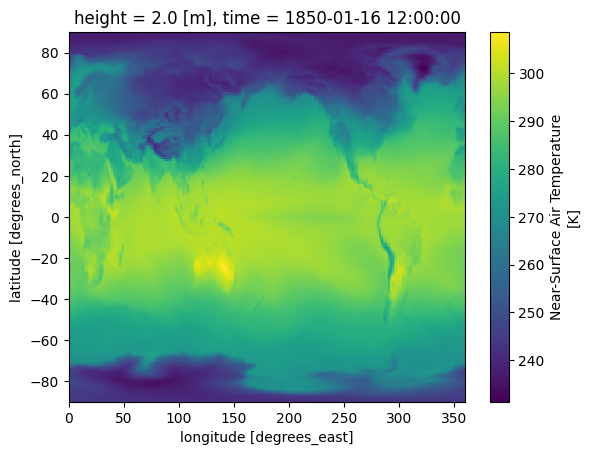

In [35]:
ds.tas.isel(time=0).plot()

In [ ]:
#TODO show use of all time periods, all ensemble members for a given experiment, compute() time check,
#data search and use of catalog
#have a central environment and binder for reproducing this